### Data Loading and Initial Inspection
This cell imports the necessary libraries (`pandas` and `numpy`) and loads the `university_admission.csv` dataset into a pandas DataFrame called `data_df`. The `data_df.head()` command then displays the first few rows of the DataFrame, providing a quick overview of the data structure and content.

In [ ]:

import pandas as pd
import numpy as np


data_df = pd.read_csv('university_admission.csv')

data_df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


### GRE Score vs. Chance of Admission Visualization
This cell visualizes the relationship between 'GRE_Score' and 'Chance_of_Admission'. It first creates a new DataFrame `df` and adds an 'Admitted' column based on a `Chance_of_Admission` threshold of 0.6. A scatter plot is generated using `seaborn` to show individual data points, with the color (`hue`) indicating whether a student is 'Admitted' or 'Not Admitted'. A regression line is overlaid to show the general trend between GRE scores and admission chances.


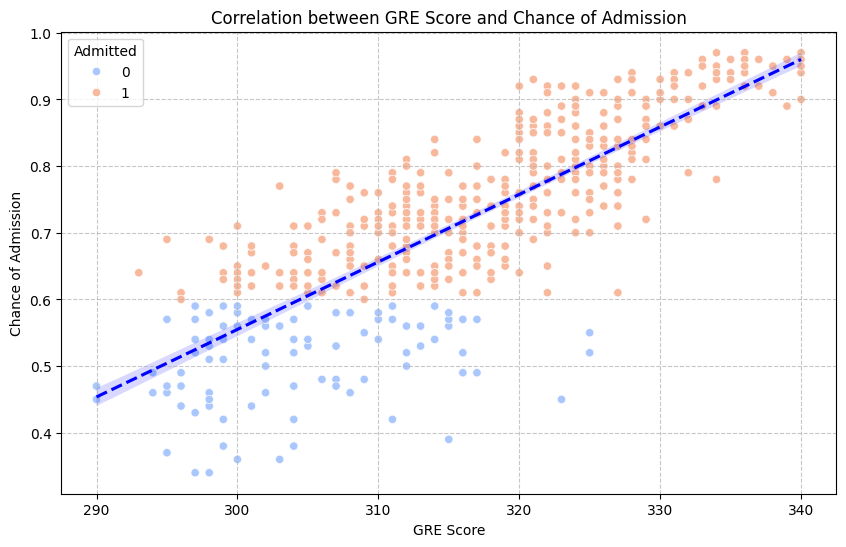

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'df' and 'Admitted' column are available for plotting
df = data_df.copy()
threshold = 0.6
df['Admitted'] = (df['Chance_of_Admission'] >= threshold).astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GRE_Score', y='Chance_of_Admission', hue='Admitted', data=df, palette='coolwarm')
sns.regplot(x='GRE_Score', y='Chance_of_Admission', data=df, scatter=False, color='blue', line_kws={'linestyle': '--'})
plt.title('Correlation between GRE Score and Chance of Admission')
plt.xlabel('GRE Score')
plt.ylabel('Chance of Admission')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Project Documentation

This notebook demonstrates a machine learning pipeline for predicting university admissions. It includes data loading, preprocessing, model training, and deployment using Streamlit and LangGraph.

In [ ]:
data_df.describe()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


In [ ]:
data_columns = list(data_df.columns)
print(data_columns)

['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance_of_Admission']


===== Admitted/Not_adminted Count : =====
 Admitted
1    810
0    190
Name: count, dtype: int64


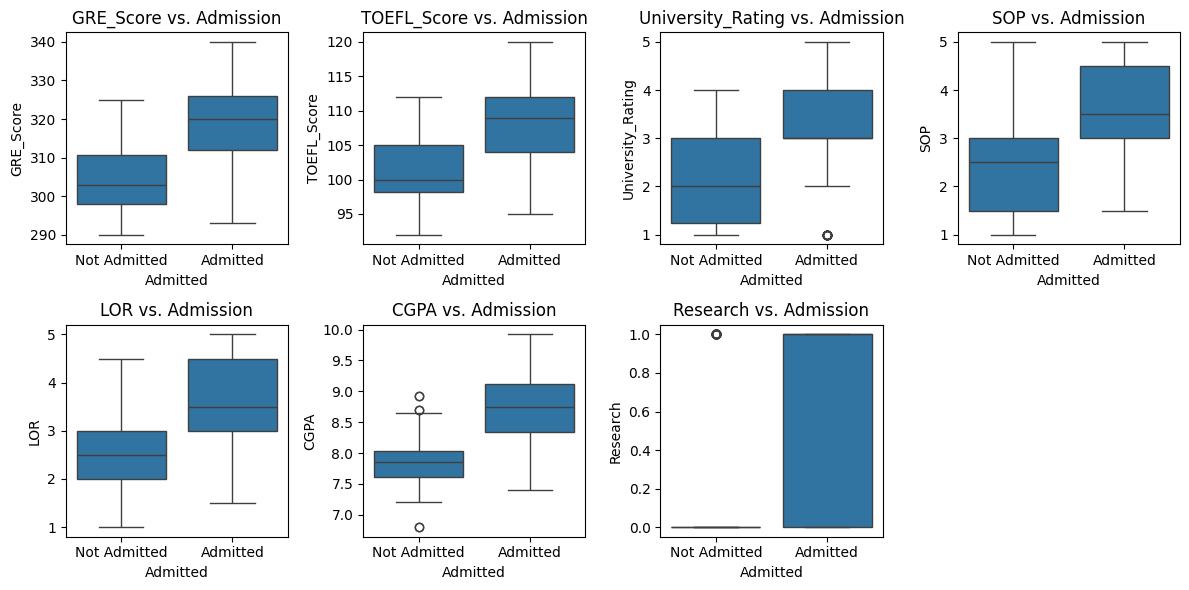

In [ ]:
df = data_df.copy()

threshold = 0.6

df['Admitted'] = (df['Chance_of_Admission'] >= threshold).astype(int)

df.head(20)

# check admitted/not admited number sum
print(f"===== Admitted/Not_adminted Count : =====\n {df['Admitted'].value_counts()}")

# plot plt boxplot of ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research'] against admitted
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
for col in ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']:
    plt.subplot(2, 4, data_columns.index(col) + 1)
    sns.boxplot(x='Admitted', y=col, data=df)
    plt.title(f'{col} vs. Admission')
    plt.xticks([0, 1], ['Not Admitted', 'Admitted'])

plt.tight_layout()


def generate_insights(df):
    plt.figure(figsize=(12, 5))

    # Boxplot for CGPA (the most relevant feature)
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Admitted', y='CGPA', data=df, palette='viridis')
    plt.title('CGPA Distribution by Admission Result')

    # Correlation Heatmap
    plt.subplot(1, 2, 2)
    sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.1f')
    plt.title('Feature Correlation Map')

    plt.tight_layout()
    plt.savefig('data_insights.png')
    print("Visualizations saved as 'data_insights.png'")

# generate_insights(df)

### DataFrame Information
This cell prints 'DataFrame information (columns, non-null counts, dtypes):' and then uses `data_df.info()` to display a concise summary of the DataFrame. This includes the number of entries, the number of columns, a list of all columns with their non-null count and data type, and memory usage. It's essential for understanding the data types and identifying columns with missing values.

### Cross-Validation for Overfitting Check
This cell performs k-fold cross-validation on the training data to assess the model's performance and check for overfitting. It uses `StratifiedKFold` to ensure that each fold has a similar distribution of target classes. The `cross_val_score` function calculates the accuracy for each fold, and then the mean and standard deviation of these scores are printed to provide a robust estimate of the model's performance.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform cross-validation on the training set
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation results (accuracy): {cv_results}")
print(f"Mean CV accuracy: {cv_results.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_results.std():.4f}")


Cross-validation results (accuracy): [1.      0.99375 1.      1.      1.     ]
Mean CV accuracy: 0.9988
Standard deviation of CV accuracy: 0.0025


### Descriptive Statistics (Numerical Columns)
This cell prints 'Descriptive statistics for numerical columns:' and then uses `data_df.describe()` to generate descriptive statistics for numerical columns. This output provides key statistical measures such as mean, standard deviation, min, max, and quartile values, giving a quick overview of the data's distribution and potential outliers.

### Checking for Missing Values
This cell checks for any missing (null) values across all columns in the `data_df` DataFrame using `data_df.isnull().sum()`. This is a crucial step in data preprocessing to identify and address any incomplete data entries.

In [ ]:
data_df.isnull().sum()

,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admission,0


### Correlation Heatmap
This cell generates a heatmap to visualize the correlation matrix of the `data_df` DataFrame. The `seaborn.heatmap()` function with `annot=True` displays the correlation coefficients on the map, providing insights into the linear relationships between different features.


Text(0.5, 1.0, 'Correlation Factors Heat Map')

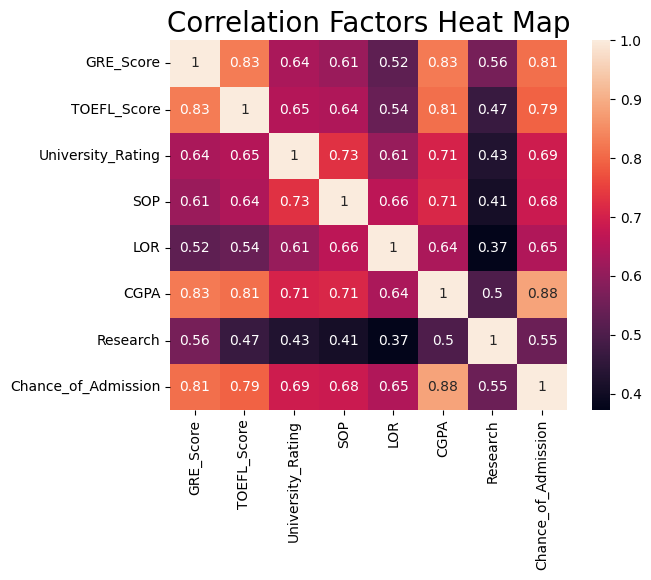

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# data_df['Program'] = label_encoder.fit_transform(data_df['Program'])


sns.heatmap(data_df.corr(), annot=True).set_title('Correlation Factors Heat Map', color='black', size='20')


In [ ]:
print("First 5 rows of the DataFrame:")
display(data_df.head())

First 5 rows of the DataFrame:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
print("DataFrame information (columns, non-null counts, dtypes):")
display(data_df.info())

DataFrame information (columns, non-null counts, dtypes):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


None

In [ ]:
print("Descriptive statistics for numerical columns:")
display(data_df.describe())

Descriptive statistics for numerical columns:


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


### Model Training Pipeline
This cell sets up and trains a machine learning pipeline:
1. It loads the `university_admission.csv` dataset and converts `Chance_of_Admission` into a binary `Admitted` column based on a threshold (0.6).
2. It defines features (`X`) and target (`y`).
3. It splits the data into training and testing sets.
4. It constructs a `Pipeline` that first scales the data using `StandardScaler` and then trains a `RandomForestClassifier`.
5. Finally, it saves the trained pipeline and the list of feature names using `joblib` for later use in prediction and deployment.

In [ ]:
# %%writefile fip_project/pipeline.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('university_admission.csv')

# The dataset has a 'Chance of Admit' (0-1). We convert it to a classification (1 = Yes, 0 = No)
threshold = 0.60
df['Admitted'] = (df['Chance_of_Admission'] >= threshold).astype(int)

# Drop the original chance and Serial No if present
X = df.drop(['Chance_of_Admission ', 'Serial No.', 'Admitted'], axis=1, errors='ignore')
y = df['Admitted']


# 4. BUILD THE PIPELINE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)

# 5. SAVE MODEL & COLUMNS
joblib.dump(pipeline, 'admission_pipeline.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("Pipeline trained and saved successfully!")


Pipeline trained and saved successfully!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform cross-validation on the training set
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation results (accuracy): {cv_results}")
print(f"Mean CV accuracy: {cv_results.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_results.std():.4f}")

Cross-validation results (accuracy): [1.      0.99375 1.      1.      1.     ]
Mean CV accuracy: 0.9988
Standard deviation of CV accuracy: 0.0025


### Model Evaluation and Feature Importance
This cell evaluates the trained Random Forest model's performance on the test set and visualizes feature importance:
1. It loads the saved `admission_pipeline.pkl` and `feature_names.pkl`.
2. It makes predictions on the `X_test` data.
3. It prints the accuracy, ROC-AUC score, and a detailed classification report.
4. It generates and displays a confusion matrix to visualize the model's classification performance.
5. Finally, it extracts and plots the feature importances from the Random Forest classifier, showing which features contributed most to the admission prediction.

Accuracy: 1.0
ROC-AUC Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00       171

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



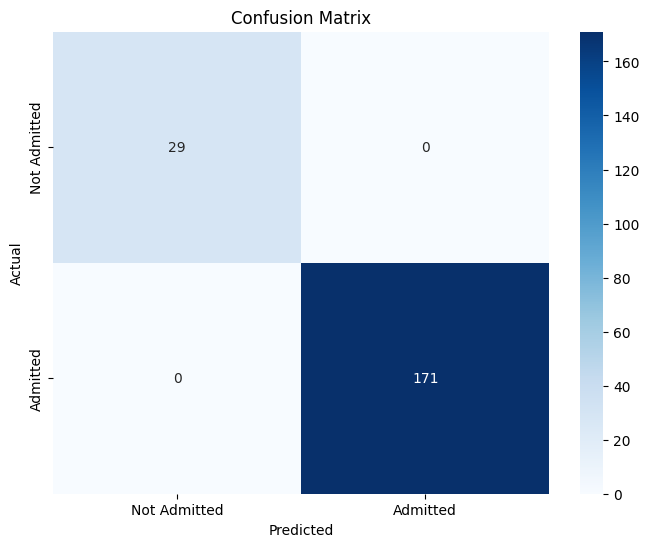

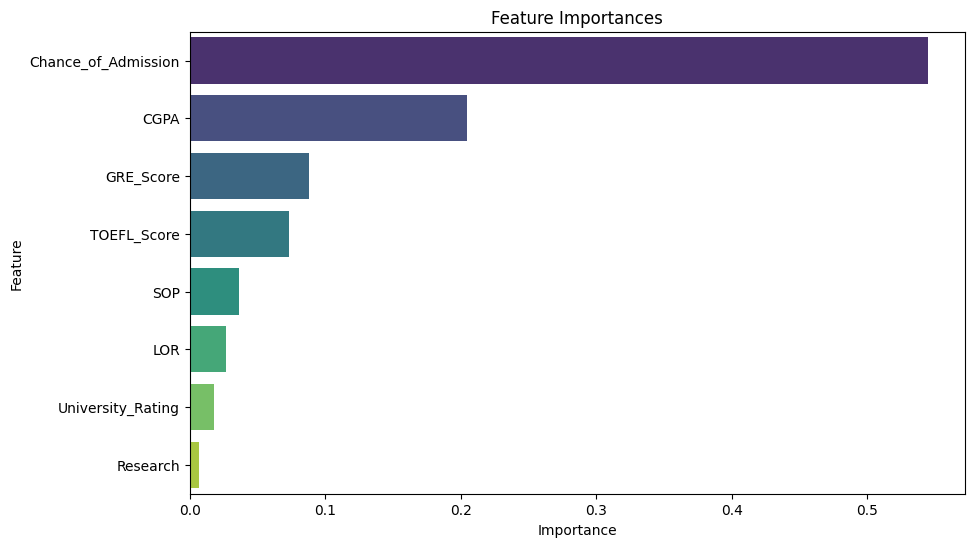

In [ ]:
# Test and plot result
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

preprocessor = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')
features_without_target = features.copy()
# Check if 'Chance_of_Admission' is in features before attempting to remove it
if 'Chance_of_Admission' in features_without_target:
    features_without_target.remove('Chance_of_Admission')

# Make predictions on the test set
# Get predicted probabilities for ROC-AUC
probabilities = preprocessor.predict_proba(X_test)[:, 1]
predicton = preprocessor.predict(X_test)

# evaluate and plot
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print(f"Accuracy: {accuracy_score(y_test, predicton)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, probabilities):.4f}")
print(classification_report(y_test, predicton))

# plot result
cm = confusion_matrix(y_test, predicton)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Admitted', 'Admitted'], yticklabels=['Not Admitted', 'Admitted'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n")
print("\n")
# Feature Importance Plot
importances = preprocessor.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, legend=False, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Perform cross-validation on the training set to check for overfitting. This will give us a better understanding of the model's generalization capabilities.

The cross-validation results show very high and consistent accuracy across all folds, with a mean accuracy of ` 99.88% ` and a standard deviation of ` 0.25%.` This indicates that the model is performing exceptionally well on unseen data within the training set and is not overfitting.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform cross-validation on the training set
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation results (accuracy): {cv_results}")
print(f"Mean CV accuracy: {cv_results.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_results.std():.4f}")


Cross-validation results (accuracy): [1.      0.99375 1.      1.      1.     ]
Mean CV accuracy: 0.9988
Standard deviation of CV accuracy: 0.0025


In [ ]:
features

['GRE_Score',
 'TOEFL_Score',
 'University_Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research',
 'Chance_of_Admission']

### AI Academic Advisor (LangGraph Agent)
This cell defines an AI Academic Advisor using `LangGraph` and `Gemini-1.5-Flash`. It loads the pre-trained admission pipeline and feature names. The `AgentState` defines the data flow for input, prediction, probability, and an explanation. The `gemini_counselor` function takes the student's data, model prediction, and probability, then uses the `ChatGoogleGenerativeAI` model to generate a professional, 3-sentence explanation focusing on how CGPA and GRE scores influenced the outcome. The workflow is then compiled as a simple graph, with the `advise` node leading directly to `END`.


In [ ]:
# %%writefile fip_project/agent.py
import os
import joblib
from typing import TypedDict

import pandas as pd
from langgraph.graph import StateGraph, END
from typing import TypedDict
from langgraph.graph import StateGraph, END

try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except:
    ! pip install langchain-google-genai
    from langchain_google_genai import ChatGoogleGenerativeAI


# --- CONFIG ---
# The GEMINI_API_KEY is already present in the kernel state.
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY

model_pipeline = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')

# --- LANGGRAPH LOGIC ---
class AgentState(TypedDict):
    input_data: dict
    prediction: int
    probability: float
    explanation: str

def gemini_counselor(state: AgentState):
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        api_key=os.environ['GOOGLE_API_KEY'], # Use the environment variable
        temperature=0.5
    )

    status = "Admitted" if state['prediction'] == 1 else "Not Admitted"

    prompt = f"""
    Context: You are an AI Academic Advisor for FlexiSAF.
    Student Data: {state['input_data']}
    Result: {status} (Confidence: {state['probability']}%)

    Instruction: Write a 3-sentence professional explanation.
    Explain how their CGPA and GRE scores specifically affected this outcome.
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

# Compile Graph
workflow = StateGraph(AgentState)
workflow.add_node("advise", gemini_counselor)
workflow.set_entry_point("advise")
workflow.add_edge("advise", END)
graph = workflow.compile()

from IPython import display
from IPython.display import Image

display.display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# %%writefile fip_project/UI_app.py
import os
import joblib
import pandas as pd
import streamlit as st

# from agent import graph

model_pipeline = joblib.load('admission_pipeline.pkl')
features = joblib.load('feature_names.pkl')


# -- STREAMLIT UI ---
st.set_page_config(page_title="FlexiSAF Admisssion AI", layout="centered")
st.title("🎓 Admission Success Predictor")

with st.sidebar:
    st.header("Enter Student Metrics")
    gre = st.number_input("GRE Score", 260, 340, 310)
    toefl = st.number_input("TOEFL Score", 0, 120, 100)
    rating = st.slider("University Rating", 1, 5, 3)
    sop = st.slider("SOP Strength", 1.0, 5.0, 3.5)
    lor = st.slider("LOR Strength", 1.0, 5.0, 3.5)
    cgpa = st.number_input("CGPA", 0.0, 10.0, 8.5)
    research = st.radio("Research Experience?", [0, 1], format_func=lambda x: "Yes" if x==1 else "No")

if st.button("Analyze Application"):
    # 1. Prediction
    input_dict = {
        'GRE_Score': gre, 'TOEFL_Score': toefl, 'University_Rating': rating,
        'SOP': sop, 'LOR': lor, 'CGPA': cgpa, 'Research': research
    }
    input_df = pd.DataFrame([input_dict])

    prob = model_pipeline.predict_proba(input_df)[0][1]
    pred = 1 if prob >= 0.5 else 0

    # 2. GenAI Explanation
    with st.spinner("Consulting AI Counselor..."):
        result = graph.invoke({
            "input_data": input_dict,
            "prediction": pred,
            "probability": round(prob * 100, 2)
        })

    # 3. UI Display
    st.divider()
    col1, col2 = st.columns(2)

    with col1:
        st.metric("Success Probability", f"{round(prob * 100, 2)}%")
        if pred == 1:
            st.success("High Admission Probability!")
        else:
            st.warning("Low Admission Probability.")

    with col2:
        st.subheader("AI Insight")
        st.write(result['explanation'])

    # Show Feature Importance Chart
    st.subheader("Feature Impact Analysis")
    importances = model_pipeline.named_steps['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values()
    st.bar_chart(feat_imp)

In [ ]:
!streamlit run fip_project/UI_app.py